<a href="https://colab.research.google.com/github/tarinishpa/stroke-boosting-ensemble/blob/main/Untitled6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost lightgbm catboost imbalanced-learn shap -q
print("All libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00
 All libraries installed!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                       f1_score, roc_auc_score, confusion_matrix,
                                       roc_curve, matthews_corrcoef, cohen_kappa_score)
from sklearn.ensemble         import VotingClassifier
from imblearn.over_sampling   import SMOTE
from xgboost                  import XGBClassifier
from lightgbm                 import LGBMClassifier
from catboost                 import CatBoostClassifier
import shap

plt.rcParams.update({'figure.dpi': 150,
                     'axes.spines.top': False,
                     'axes.spines.right': False})
print("All libraries imported!")


All libraries imported!


In [ ]:
# Load Train Dataset
df_train = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Load External Test Dataset
df_test = pd.read_csv('Test data set.csv')

print("=" * 55)
print(f"Train Dataset Shape : {df_train.shape}")
print(f"Test  Dataset Shape : {df_test.shape}")
print("=" * 55)
print("\nTrain — Stroke Distribution:")
print(df_train['stroke'].value_counts())
print("\nTest  — Stroke Distribution:")
print(df_test['stroke'].value_counts())
print("\nTrain Columns:", list(df_train.columns))
print("Test  Columns:", list(df_test.columns))


Train Dataset Shape : (5110, 12)
Test  Dataset Shape : (38290, 12)

Train — Stroke Distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

Test  — Stroke Distribution:
stroke
0    37756
1      534
Name: count, dtype: int64

Train Columns: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']
Test  Columns: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [ ]:
def preprocess(df, name="Dataset"):
    df = df.copy()
    if 'id' in df.columns:
        df.drop('id', axis=1, inplace=True)
    # BMI imputation
    if 'bmi' in df.columns:
        df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
        df['bmi'].fillna(df['bmi'].median(), inplace=True)
    # Categorical encoding
    le = LabelEncoder()
    for col in df.select_dtypes(include='object').columns:
        df[col] = le.fit_transform(df[col].astype(str))
    X = df.drop('stroke', axis=1)
    y = df['stroke']
    print(f" {name} preprocessed — Shape: {X.shape}")
    return X, y

X_train_raw, y_train = preprocess(df_train, "Train Dataset")
X_test_raw,  y_test  = preprocess(df_test,  "Test Dataset")

# Common features only
common_cols = list(set(X_train_raw.columns) & set(X_test_raw.columns))
print(f"\nCommon features ({len(common_cols)}): {common_cols}")

X_train_raw = X_train_raw[common_cols]
X_test_raw  = X_test_raw[common_cols]

# Scale — fit on train ONLY, transform both
scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=common_cols)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),      columns=common_cols)

print("\nScaling done (fit on train only — no data leakage)")


 Train Dataset preprocessed — Shape: (5110, 10)
 Test Dataset preprocessed — Shape: (38290, 10)

Common features (10): ['avg_glucose_level', 'work_type', 'ever_married', 'gender', 'age', 'smoking_status', 'hypertension', 'heart_disease', 'Residence_type', 'bmi']

 Scaling done (fit on train only — no data leakage)


SMOTE applied to TRAIN ONLY (never on test set)
Before SMOTE: {0: np.int64(4861), 1: np.int64(249)}
After  SMOTE: {1: np.int64(4861), 0: np.int64(4861)}


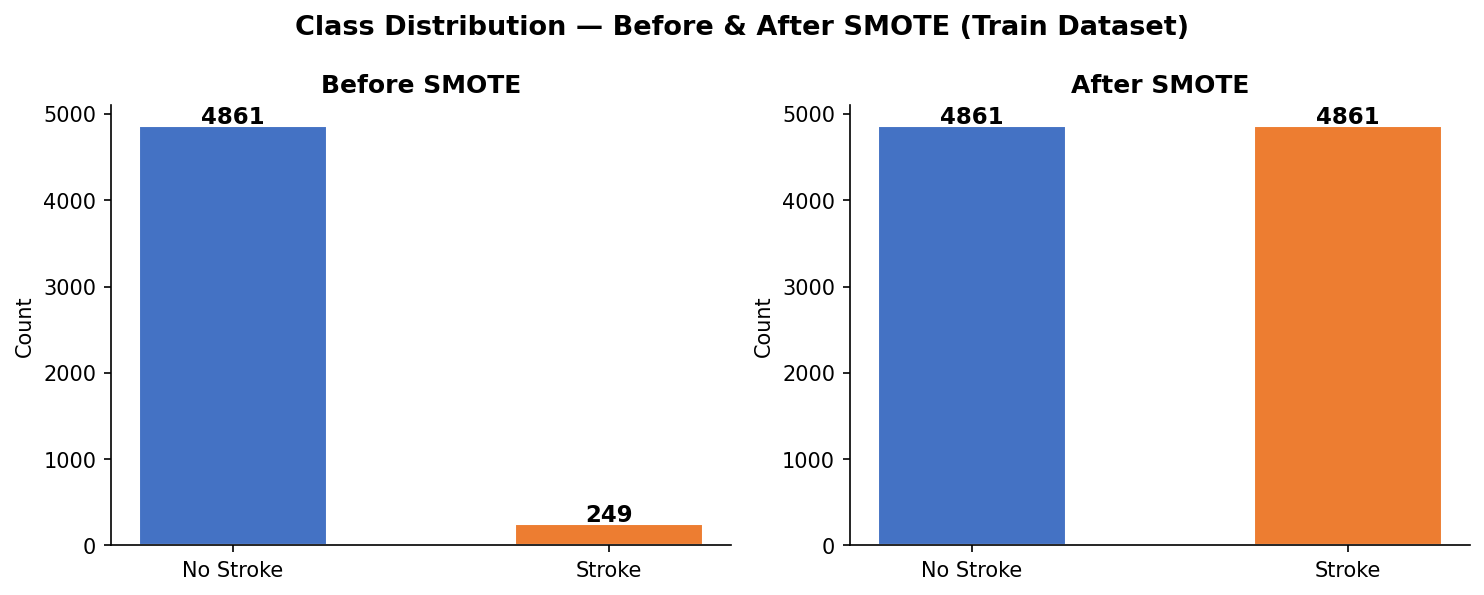

 Saved: 01_smote_distribution.png


In [ ]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("SMOTE applied to TRAIN ONLY (never on test set)")
print(f"Before SMOTE: {dict(y_train.value_counts())}")
print(f"After  SMOTE: {dict(y_train_sm.value_counts())}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Class Distribution — Before & After SMOTE (Train Dataset)',
             fontsize=13, fontweight='bold')

for ax, (y_data, label) in zip(axes, [(y_train,"Before SMOTE"),(y_train_sm,"After SMOTE")]):
    counts = y_data.value_counts().sort_index()
    bars = ax.bar(['No Stroke','Stroke'], counts.values,
                  color=['#4472C4','#ED7D31'], edgecolor='white', width=0.5)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v+30, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('01_smote_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_smote_distribution.png")


In [ ]:
def make_models():
    xgb = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, verbosity=0)
    lgbm = LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        random_state=42, verbose=-1)
    cat = CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05,
        random_state=42, verbose=0)
    ensemble = VotingClassifier(
        estimators=[('XGBoost',xgb),('LightGBM',lgbm),('CatBoost',cat)],
        voting='soft')
    return {
        'XGBoost'               : xgb,
        'LightGBM'              : lgbm,
        'CatBoost'              : cat,
        'Ensemble (Soft Voting)': ensemble
    }

models = make_models()
print("Models defined:")
for k in models: print(f"   • {k}")


 Models defined:
   • XGBoost
   • LightGBM
   • CatBoost
   • Ensemble (Soft Voting)


SMOTE Effect on Ensemble:
             Before SMOTE  After SMOTE
Accuracy           0.9481       0.9573
Precision          0.3333       0.9645
Recall             0.0600       0.9496
Specificity        0.9938       0.9651
F1-Score           0.1017       0.9570
AUC-ROC            0.8291       0.9910
MCC                0.1243       0.9148
Kappa              0.0881       0.9147


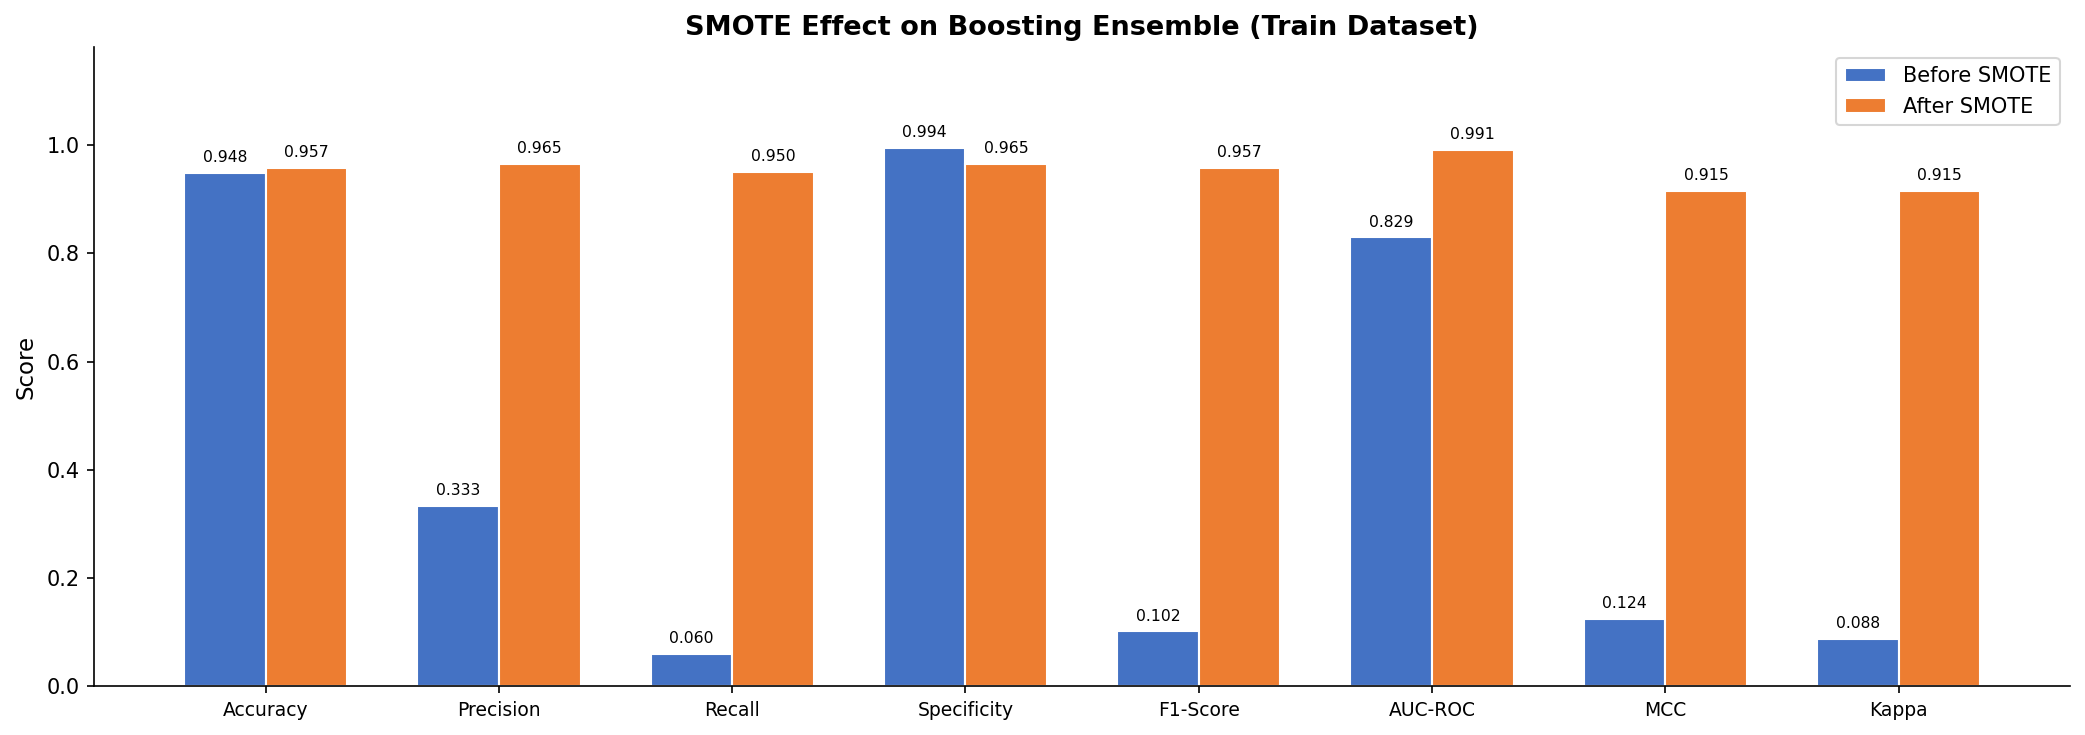

Saved: 02_smote_effect.png


In [ ]:
def get_ensemble_metrics(X_tr, y_tr, X_te, y_te):
    ens = VotingClassifier(
        estimators=[
            ('XGBoost',  XGBClassifier(n_estimators=300, max_depth=6,
                learning_rate=0.05, use_label_encoder=False,
                eval_metric='logloss', random_state=42, verbosity=0)),
            ('LightGBM', LGBMClassifier(n_estimators=300, max_depth=6,
                learning_rate=0.05, random_state=42, verbose=-1)),
            ('CatBoost', CatBoostClassifier(iterations=300, depth=6,
                learning_rate=0.05, random_state=42, verbose=0)),
        ], voting='soft')
    ens.fit(X_tr, y_tr)
    y_pred = ens.predict(X_te)
    y_prob = ens.predict_proba(X_te)[:,1]
    cm = confusion_matrix(y_te, y_pred)
    tn,fp,fn,tp = cm.ravel()
    return {
        'Accuracy'   : round(accuracy_score(y_te,y_pred),4),
        'Precision'  : round(precision_score(y_te,y_pred,zero_division=0),4),
        'Recall'     : round(recall_score(y_te,y_pred,zero_division=0),4),
        'Specificity': round(tn/(tn+fp) if (tn+fp)>0 else 0,4),
        'F1-Score'   : round(f1_score(y_te,y_pred,zero_division=0),4),
        'AUC-ROC'    : round(roc_auc_score(y_te,y_prob),4),
        'MCC'        : round(matthews_corrcoef(y_te,y_pred),4),
        'Kappa'      : round(cohen_kappa_score(y_te,y_pred),4),
    }

# Split train for before/after comparison
X_tr, X_te, y_tr, y_te = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_train_sm, y_train_sm, test_size=0.2, random_state=42, stratify=y_train_sm)

before = get_ensemble_metrics(X_tr,   y_tr,   X_te,   y_te)
after  = get_ensemble_metrics(X_tr_s, y_tr_s, X_te_s, y_te_s)

smote_df = pd.DataFrame({'Before SMOTE':before,'After SMOTE':after})
smote_df.to_csv('smote_effect.csv')
print("SMOTE Effect on Ensemble:")
print(smote_df)

metrics_s = ['Accuracy','Precision','Recall','Specificity','F1-Score','AUC-ROC','MCC','Kappa']
x = np.arange(len(metrics_s)); w=0.35
fig, ax = plt.subplots(figsize=(14,5))
b1 = ax.bar(x-w/2,[before[m] for m in metrics_s],w,
            label='Before SMOTE',color='#4472C4',edgecolor='white')
b2 = ax.bar(x+w/2,[after[m]  for m in metrics_s],w,
            label='After SMOTE', color='#ED7D31',edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(metrics_s,fontsize=9)
ax.set_ylim(0,1.18); ax.set_ylabel('Score',fontsize=11)
ax.set_title('SMOTE Effect on Boosting Ensemble (Train Dataset)',
             fontsize=13,fontweight='bold')
ax.legend(fontsize=10)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=7.5)
plt.tight_layout()
plt.savefig('02_smote_effect.png',dpi=150,bbox_inches='tight')
plt.show()
print(" Saved: 02_smote_effect.png")


In [ ]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy','precision','recall','f1','roc_auc']

res_cv = {}
print(" 10-Fold CV on Train Dataset (with SMOTE)\n")
for name, model in make_models().items():
    cv = cross_validate(model, X_train_sm, y_train_sm,
                        cv=skf, scoring=scoring, n_jobs=-1)
    res_cv[name] = {
        'Accuracy'  : round(cv['test_accuracy'].mean(),4),
        'Precision' : round(cv['test_precision'].mean(),4),
        'Recall'    : round(cv['test_recall'].mean(),4),
        'F1-Score'  : round(cv['test_f1'].mean(),4),
        'AUC-ROC'   : round(cv['test_roc_auc'].mean(),4),
        'Acc±Std'   : f"{cv['test_accuracy'].mean():.4f}±{cv['test_accuracy'].std():.4f}",
        'AUC±Std'   : f"{cv['test_roc_auc'].mean():.4f}±{cv['test_roc_auc'].std():.4f}",
    }
    print(f"  {name:30s} | Acc={res_cv[name]['Accuracy']} "
          f"| F1={res_cv[name]['F1-Score']} | AUC={res_cv[name]['AUC-ROC']}")

df_cv = pd.DataFrame(res_cv).T
df_cv.to_csv('cv_train_results.csv')
print("\n Saved: cv_train_results.csv")
print("\n10-Fold CV Results (Train Dataset):")
print(df_cv[['Accuracy','Precision','Recall','F1-Score','AUC-ROC']])


 10-Fold CV on Train Dataset (with SMOTE)

  XGBoost                        | Acc=0.9542 | F1=0.9539 | AUC=0.9912
  LightGBM                       | Acc=0.9569 | F1=0.9564 | AUC=0.9912
  CatBoost                       | Acc=0.9456 | F1=0.9453 | AUC=0.9898
  Ensemble (Soft Voting)         | Acc=0.9559 | F1=0.9554 | AUC=0.9919

 Saved: cv_train_results.csv

10-Fold CV Results (Train Dataset):
                       Accuracy Precision  Recall F1-Score AUC-ROC
XGBoost                  0.9542    0.9608  0.9471   0.9539  0.9912
LightGBM                 0.9569    0.9668  0.9463   0.9564  0.9912
CatBoost                 0.9456    0.9501  0.9408   0.9453  0.9898
Ensemble (Soft Voting)   0.9559     0.965  0.9461   0.9554  0.9919


In [ ]:
# Train on FULL train dataset (with SMOTE), test on external dataset
ext_res = {}
print(" Train on Dataset 1 → Test on External Dataset\n")

for name, model in make_models().items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    cm = confusion_matrix(y_test, y_pred)
    tn,fp,fn,tp = cm.ravel()
    ext_res[name] = {
        'Accuracy'       : round(accuracy_score(y_test,y_pred),4),
        'Precision'      : round(precision_score(y_test,y_pred,zero_division=0),4),
        'Recall (Sens.)' : round(recall_score(y_test,y_pred,zero_division=0),4),
        'Specificity'    : round(tn/(tn+fp) if (tn+fp)>0 else 0,4),
        'F1-Score'       : round(f1_score(y_test,y_pred,zero_division=0),4),
        'AUC-ROC'        : round(roc_auc_score(y_test,y_prob),4),
        'MCC'            : round(matthews_corrcoef(y_test,y_pred),4),
        'Kappa'          : round(cohen_kappa_score(y_test,y_pred),4),
    }
    print(f"  {name:30s} | Acc={ext_res[name]['Accuracy']} "
          f"| F1={ext_res[name]['F1-Score']} | AUC={ext_res[name]['AUC-ROC']}")

df_ext = pd.DataFrame(ext_res).T
df_ext.to_csv('external_test_results.csv')
print("\n Saved: external_test_results.csv")
print("\nExternal Test Full Results:")
print(df_ext)


Train on Dataset 1 → Test on External Dataset

  XGBoost                        | Acc=0.9581 | F1=0.0664 | AUC=0.7879
  LightGBM                       | Acc=0.9601 | F1=0.0694 | AUC=0.7855
  CatBoost                       | Acc=0.9511 | F1=0.0759 | AUC=0.7875
  Ensemble (Soft Voting)         | Acc=0.961 | F1=0.0651 | AUC=0.7902

Saved: external_test_results.csv

External Test Full Results:
                        Accuracy  Precision  Recall (Sens.)  Specificity  \
XGBoost                   0.9581     0.0482          0.1067       0.9702   
LightGBM                  0.9601     0.0514          0.1067       0.9722   
CatBoost                  0.9511     0.0515          0.1442       0.9625   
Ensemble (Soft Voting)    0.9610     0.0489          0.0974       0.9732   

                        F1-Score  AUC-ROC     MCC   Kappa  
XGBoost                   0.0664   0.7879  0.0521  0.0481  
LightGBM                  0.0694   0.7855  0.0552  0.0516  
CatBoost                  0.0759   0.7875  0.0

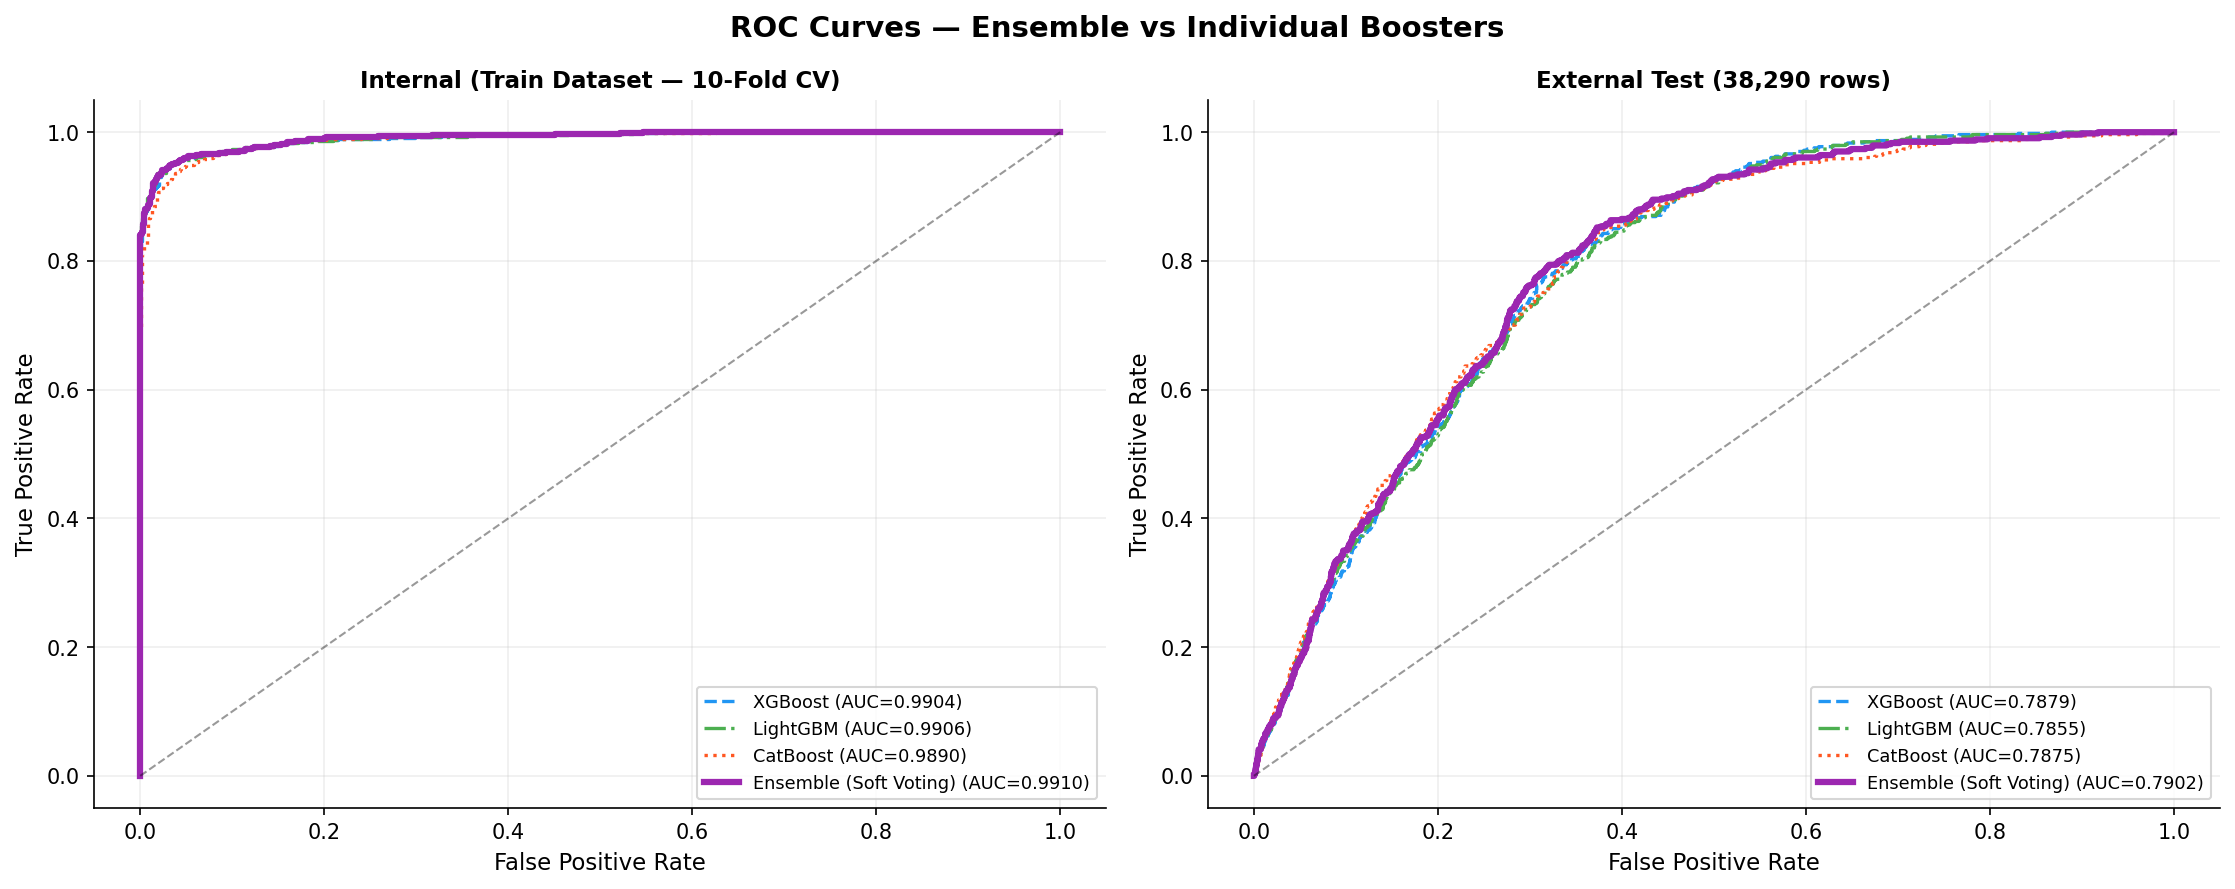

Saved: 03_roc_curves.png


In [ ]:
line_colors = ['#2196F3','#4CAF50','#FF5722','#9C27B0']
line_styles = ['--','-.', ':',  '-']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ROC Curves — Ensemble vs Individual Boosters',
             fontsize=14, fontweight='bold')

# Left: 10-Fold CV Internal (Train)
ax = axes[0]
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_train_sm, y_train_sm, test_size=0.2, random_state=42, stratify=y_train_sm)

for (name,model),col,ls in zip(make_models().items(), line_colors, line_styles):
    model.fit(X_tr2, y_tr2)
    y_prob = model.predict_proba(X_te2)[:,1]
    fpr,tpr,_ = roc_curve(y_te2, y_prob)
    auc = roc_auc_score(y_te2, y_prob)
    lw = 3 if 'Ensemble' in name else 1.6
    ax.plot(fpr,tpr,color=col,lw=lw,ls=ls,label=f"{name} (AUC={auc:.4f})")
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax.set_xlabel('False Positive Rate',fontsize=11)
ax.set_ylabel('True Positive Rate',fontsize=11)
ax.set_title('Internal (Train Dataset — 10-Fold CV)',fontweight='bold',fontsize=11)
ax.legend(loc='lower right',fontsize=8.5)
ax.grid(alpha=0.2)

# Right: External Test
ax = axes[1]
for (name,model),col,ls in zip(make_models().items(), line_colors, line_styles):
    model.fit(X_train_sm, y_train_sm)
    y_prob = model.predict_proba(X_test)[:,1]
    fpr,tpr,_ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    lw = 3 if 'Ensemble' in name else 1.6
    ax.plot(fpr,tpr,color=col,lw=lw,ls=ls,label=f"{name} (AUC={auc:.4f})")
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax.set_xlabel('False Positive Rate',fontsize=11)
ax.set_ylabel('True Positive Rate',fontsize=11)
ax.set_title('External Test (38,290 rows)',fontweight='bold',fontsize=11)
ax.legend(loc='lower right',fontsize=8.5)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('03_roc_curves.png',dpi=150,bbox_inches='tight')
plt.show()
print(" Saved: 03_roc_curves.png")


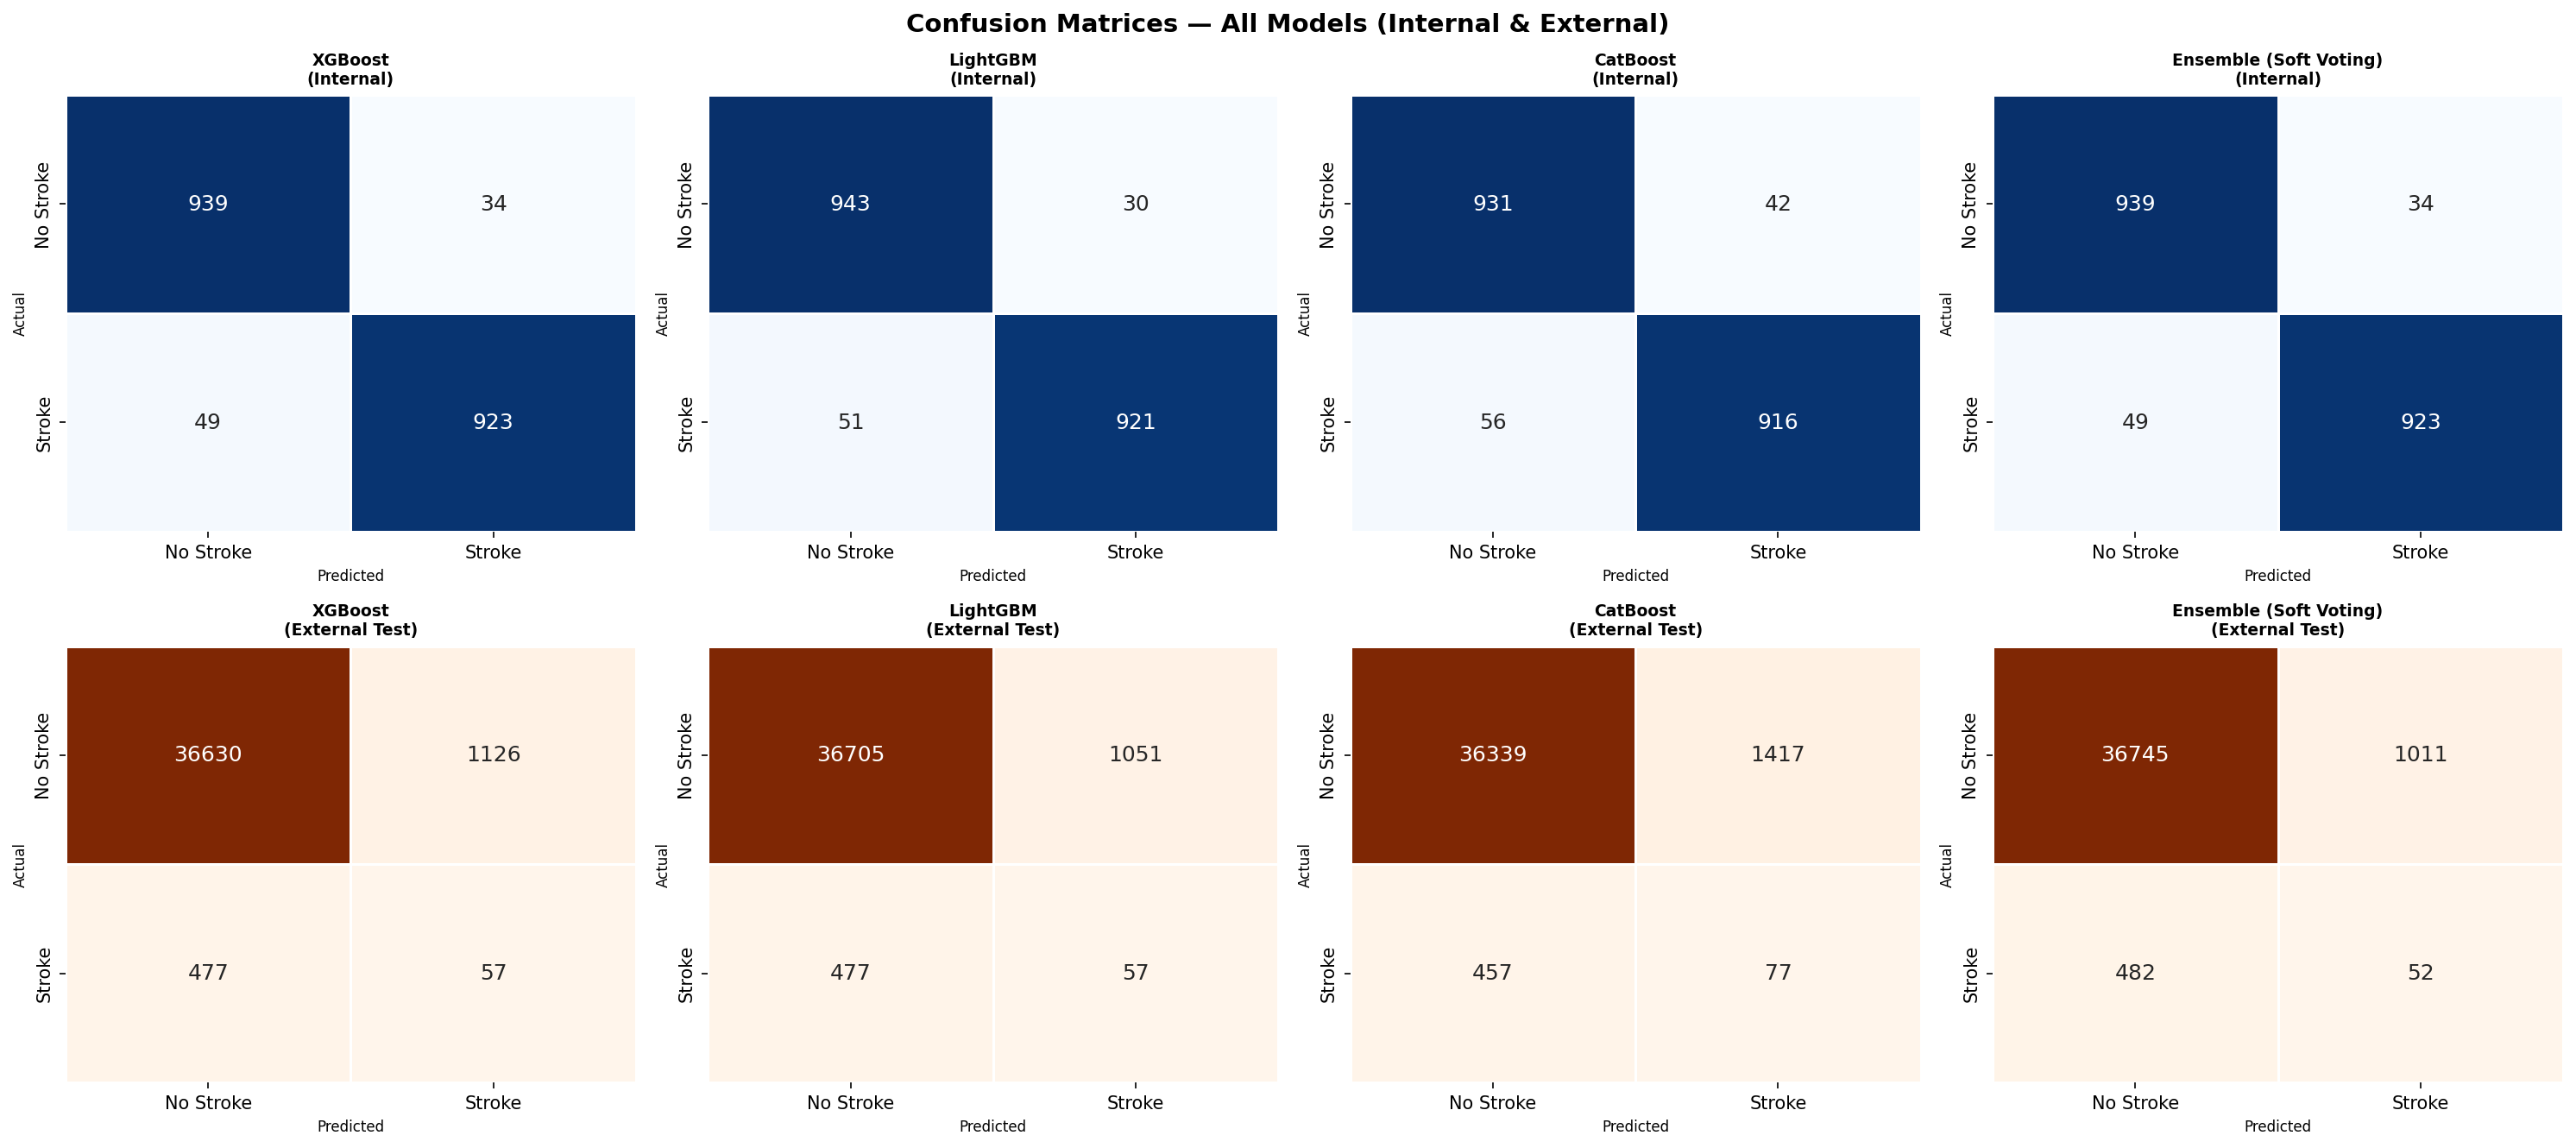

Saved: 04_confusion_matrix.png


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Confusion Matrices — All Models (Internal & External)',
             fontsize=14, fontweight='bold')

X_tr3, X_te3, y_tr3, y_te3 = train_test_split(
    X_train_sm, y_train_sm, test_size=0.2, random_state=42, stratify=y_train_sm)

for col,(name,model) in enumerate(make_models().items()):
    # Internal
    model.fit(X_tr3, y_tr3)
    cm = confusion_matrix(y_te3, model.predict(X_te3))
    ax = axes[0][col]
    sns.heatmap(cm,annot=True,fmt='d',ax=ax,cmap='Blues',
                linewidths=0.5,cbar=False,annot_kws={"size":12},
                xticklabels=['No Stroke','Stroke'],
                yticklabels=['No Stroke','Stroke'])
    ax.set_title(f'{name}\n(Internal)',fontsize=9,fontweight='bold')
    ax.set_xlabel('Predicted',fontsize=8)
    ax.set_ylabel('Actual',fontsize=8)

    # External
    model.fit(X_train_sm, y_train_sm)
    cm2 = confusion_matrix(y_test, model.predict(X_test))
    ax2 = axes[1][col]
    sns.heatmap(cm2,annot=True,fmt='d',ax=ax2,cmap='Oranges',
                linewidths=0.5,cbar=False,annot_kws={"size":12},
                xticklabels=['No Stroke','Stroke'],
                yticklabels=['No Stroke','Stroke'])
    ax2.set_title(f'{name}\n(External Test)',fontsize=9,fontweight='bold')
    ax2.set_xlabel('Predicted',fontsize=8)
    ax2.set_ylabel('Actual',fontsize=8)

plt.tight_layout()
plt.savefig('04_confusion_matrix.png',dpi=150,bbox_inches='tight')
plt.show()
print(" Saved: 04_confusion_matrix.png")


Top 10 Features (Normalised):
                   XGBoost  LightGBM  CatBoost    Mean
age                 1.0000    1.0000    0.5030  0.8343
smoking_status      0.6109    0.4192    1.0000  0.6767
work_type           0.6525    0.3522    0.6636  0.5561
avg_glucose_level   0.1622    0.7213    0.1717  0.3518
bmi                 0.1635    0.6202    0.1586  0.3141
ever_married        0.3407    0.0781    0.1037  0.1742
gender              0.2162    0.1681    0.1166  0.1670
Residence_type      0.2139    0.1652    0.1170  0.1654
heart_disease       0.1875    0.0682    0.0343  0.0967
hypertension        0.1573    0.0604    0.0266  0.0814


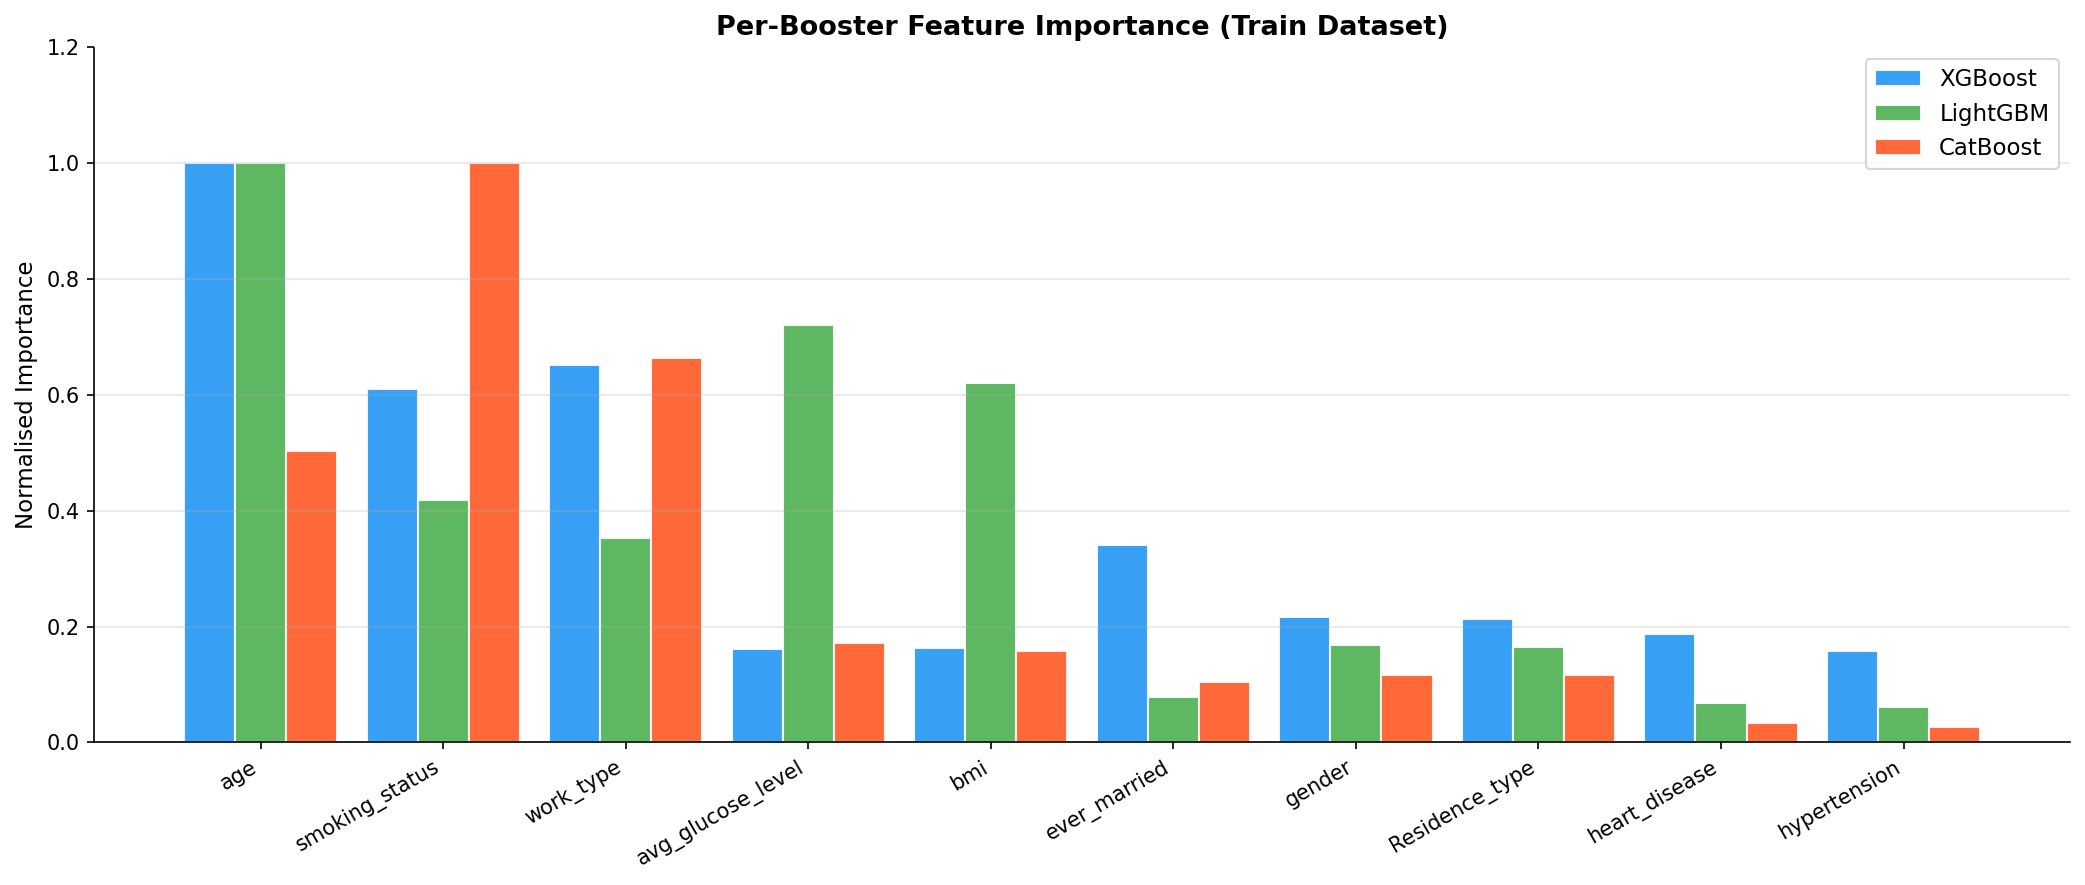

 Saved: 05_feature_importance.png


In [ ]:
xgb_fi  = XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,
                          use_label_encoder=False,eval_metric='logloss',
                          random_state=42,verbosity=0)
lgbm_fi = LGBMClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,
                           random_state=42,verbose=-1)
cat_fi  = CatBoostClassifier(iterations=300,depth=6,learning_rate=0.05,
                               random_state=42,verbose=0)

xgb_fi.fit(X_train_sm, y_train_sm)
lgbm_fi.fit(X_train_sm, y_train_sm)
cat_fi.fit(X_train_sm, y_train_sm)

feat_df = pd.DataFrame({
    'XGBoost'  : xgb_fi.feature_importances_,
    'LightGBM' : lgbm_fi.feature_importances_,
    'CatBoost' : cat_fi.feature_importances_,
}, index=X_train_sm.columns)
feat_df = feat_df.div(feat_df.max())
feat_df['Mean'] = feat_df.mean(axis=1)
feat_df = feat_df.sort_values('Mean',ascending=False)
feat_df.to_csv('feature_importance.csv')

print("Top 10 Features (Normalised):")
print(feat_df.head(10).round(4))

top = feat_df.head(10)[['XGBoost','LightGBM','CatBoost']]
x   = np.arange(len(top)); w=0.28
fig, ax = plt.subplots(figsize=(14,6))
for i,(col,c) in enumerate(zip(['XGBoost','LightGBM','CatBoost'],
                                 ['#2196F3','#4CAF50','#FF5722'])):
    ax.bar(x+(i-1)*w,top[col],w,label=col,color=c,edgecolor='white',alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(top.index,rotation=30,ha='right',fontsize=10)
ax.set_ylabel('Normalised Importance',fontsize=11)
ax.set_title('Per-Booster Feature Importance (Train Dataset)',
             fontsize=13,fontweight='bold')
ax.legend(fontsize=11); ax.set_ylim(0,1.2); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig('05_feature_importance.png',dpi=150,bbox_inches='tight')
plt.show()
print("Saved: 05_feature_importance.png")


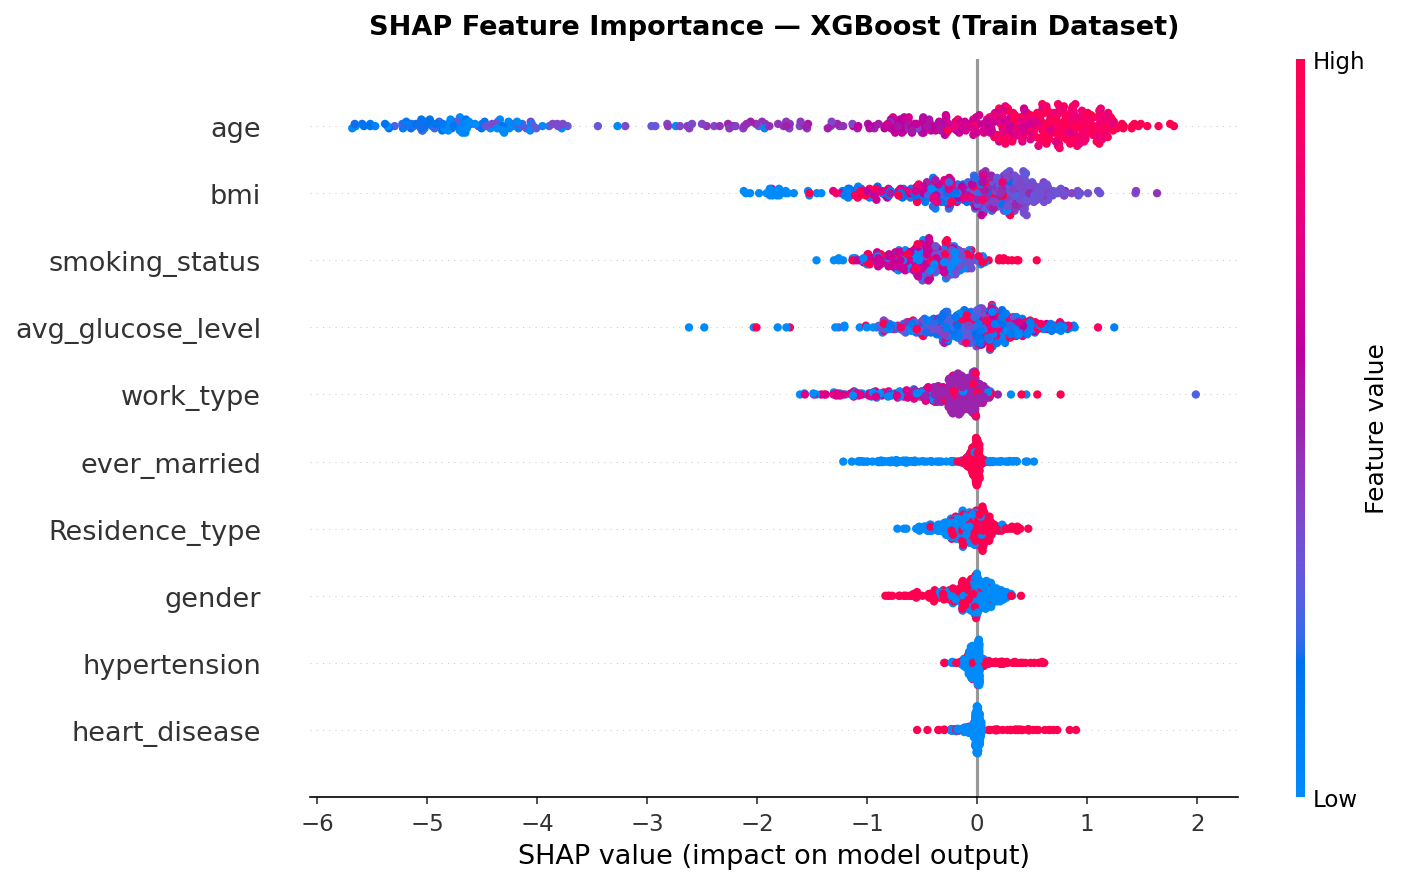

Saved: 06_shap_summary.png


In [ ]:
explainer = shap.TreeExplainer(xgb_fi)
shap_vals = explainer.shap_values(X_train_sm.iloc[:500])

plt.figure(figsize=(10,6))
shap.summary_plot(shap_vals, X_train_sm.iloc[:500], show=False, plot_size=None)
plt.title('SHAP Feature Importance — XGBoost (Train Dataset)',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('06_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_shap_summary.png")


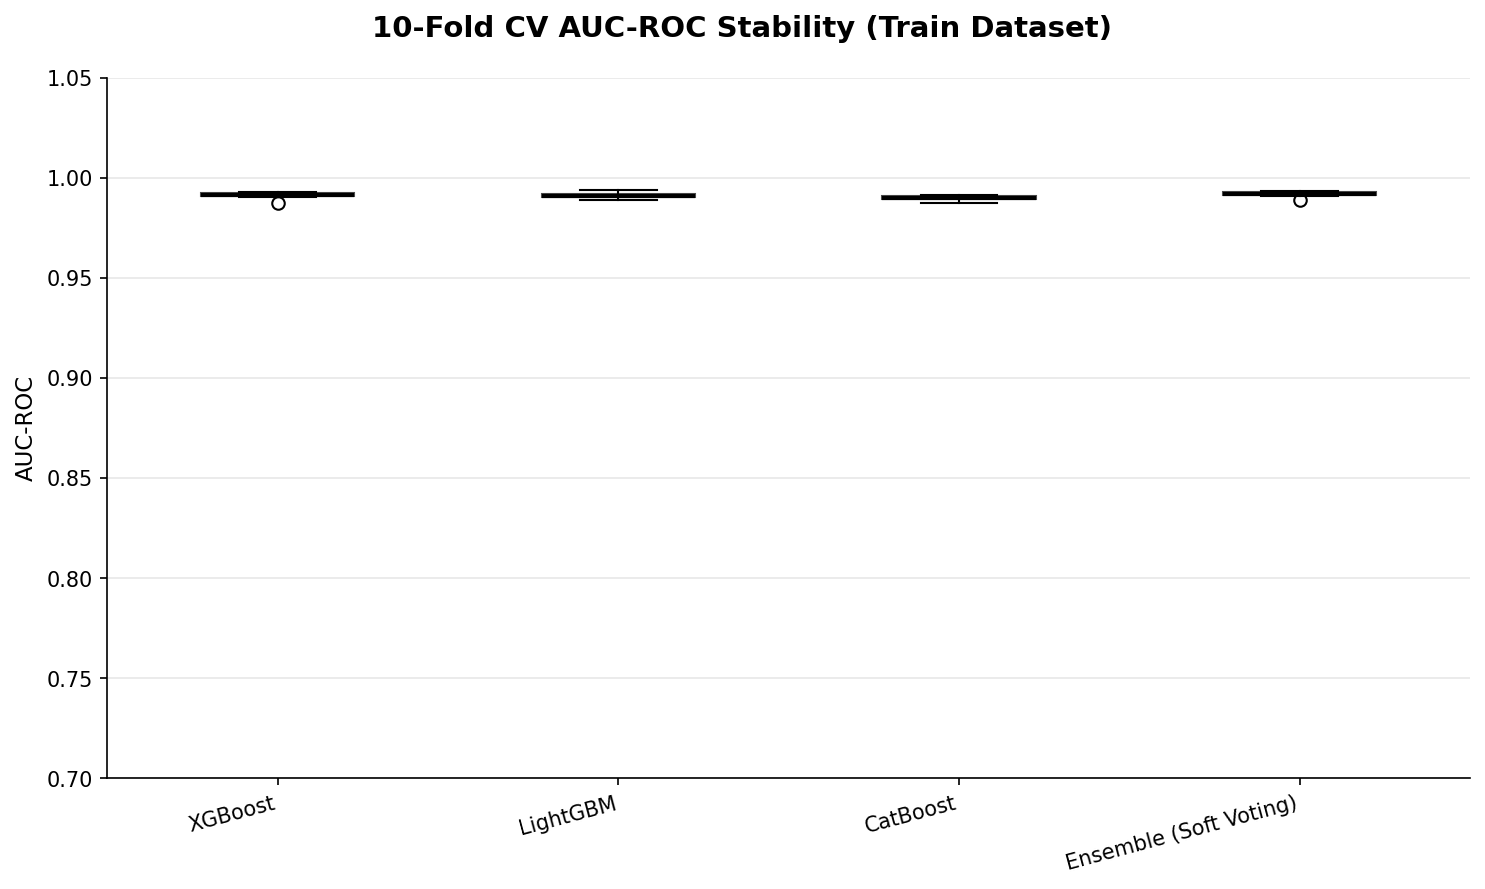

 Saved: 07_cv_boxplot.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('10-Fold CV AUC-ROC Stability (Train Dataset)',
             fontsize=14, fontweight='bold')

box_data=[]; labels=[]
for name,model in make_models().items():
    cv = cross_validate(model, X_train_sm, y_train_sm,
                        cv=skf, scoring=['roc_auc'], n_jobs=-1)
    box_data.append(cv['test_roc_auc']); labels.append(name)

bp = ax.boxplot(box_data, patch_artist=True,
                medianprops=dict(color='black',lw=2))
for patch,color in zip(bp['boxes'],
        ['#2196F3','#4CAF50','#FF5722','#9C27B0']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_ylim(0.7, 1.05); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('07_cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 07_cv_boxplot.png")


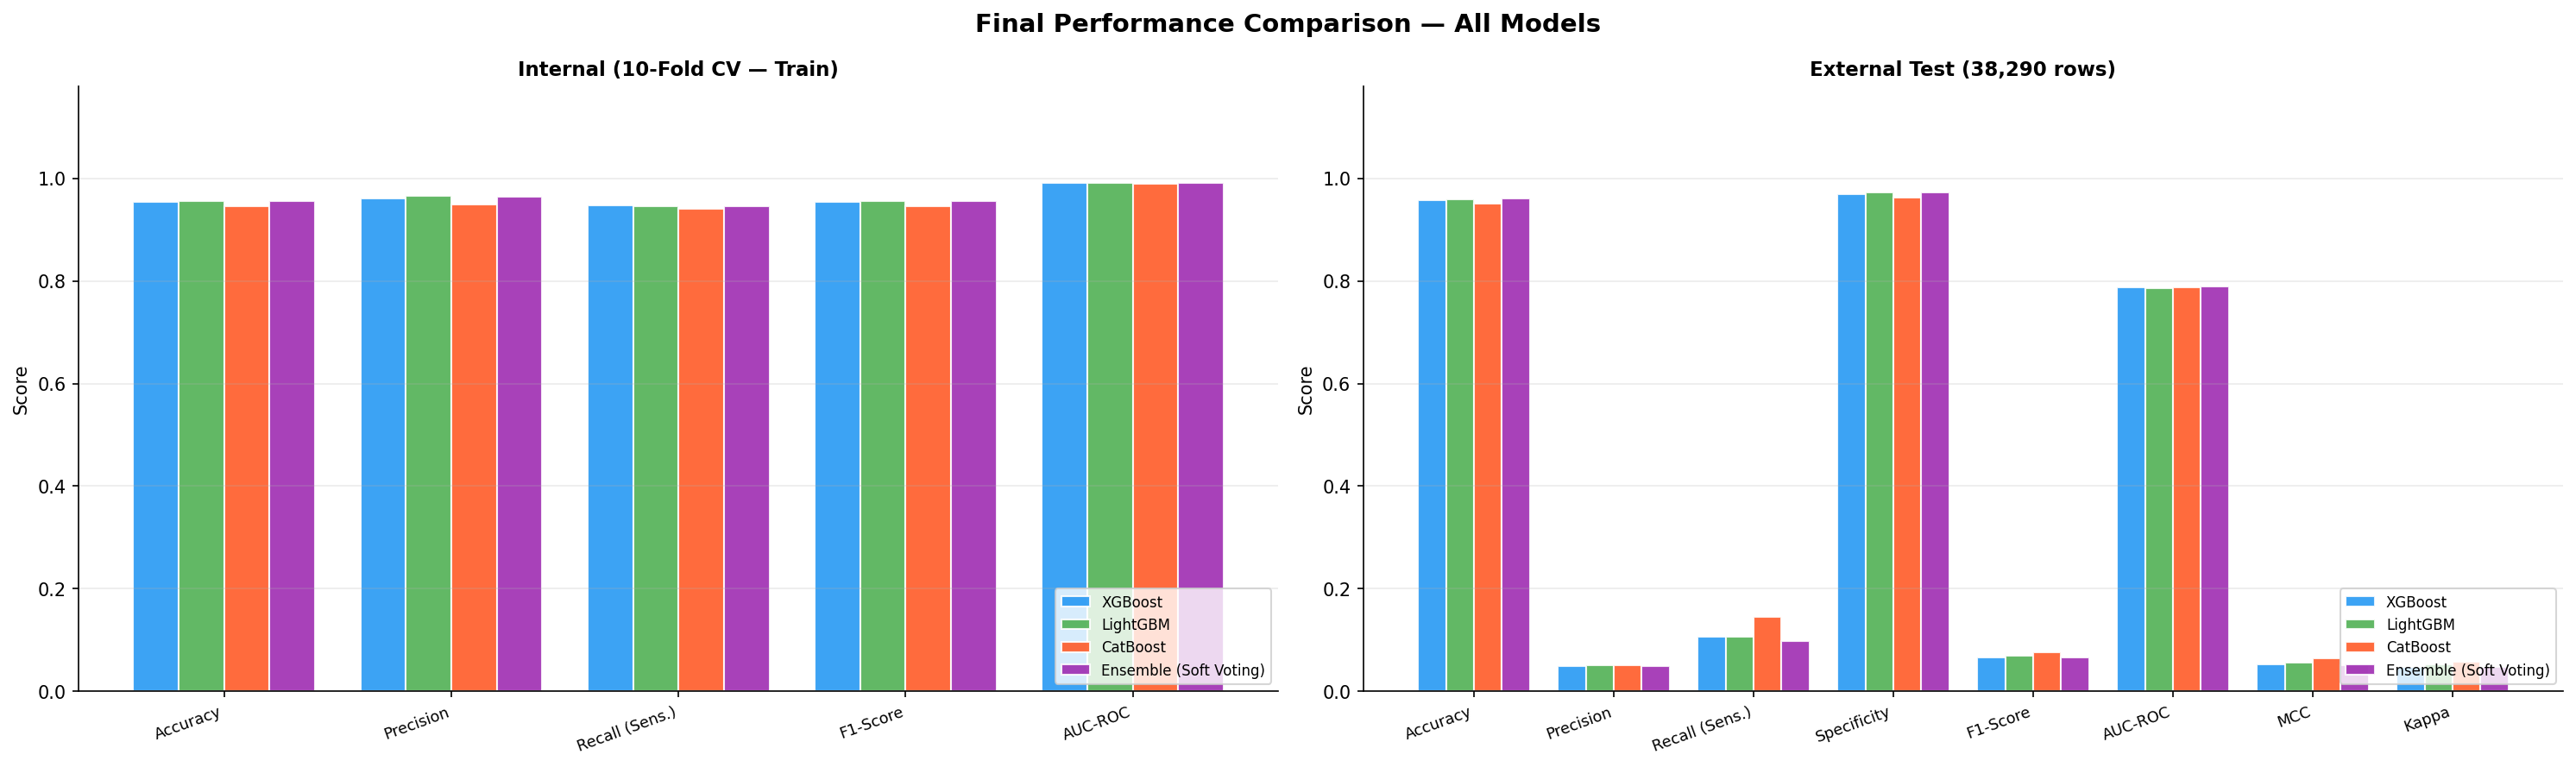

 Saved: 08_final_comparison.png


In [ ]:
metrics_plot = ['Accuracy','Precision','Recall (Sens.)','Specificity',
                'F1-Score','AUC-ROC','MCC','Kappa']

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Final Performance Comparison — All Models',
             fontsize=14, fontweight='bold')

for ax, (data, ds_name) in zip(axes, [
        (pd.DataFrame(res_cv).T.rename(columns={'Recall':'Recall (Sens.)'}),
         'Internal (10-Fold CV — Train)'),
        (df_ext, 'External Test (38,290 rows)')]):

    available = [m for m in metrics_plot if m in data.columns]
    x  = np.arange(len(available)); w=0.2
    colors_bar=['#2196F3','#4CAF50','#FF5722','#9C27B0']
    for i,(mname,col) in enumerate(zip(data.index,colors_bar)):
        vals = [float(data.loc[mname,m]) for m in available]
        ax.bar(x+(i-1.5)*w, vals, w, label=mname,
               color=col, edgecolor='white', alpha=0.88)
    ax.set_xticks(x)
    ax.set_xticklabels(available, rotation=20, ha='right', fontsize=8.5)
    ax.set_ylim(0,1.18); ax.set_ylabel('Score',fontsize=10)
    ax.set_title(ds_name, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('08_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 08_final_comparison.png")


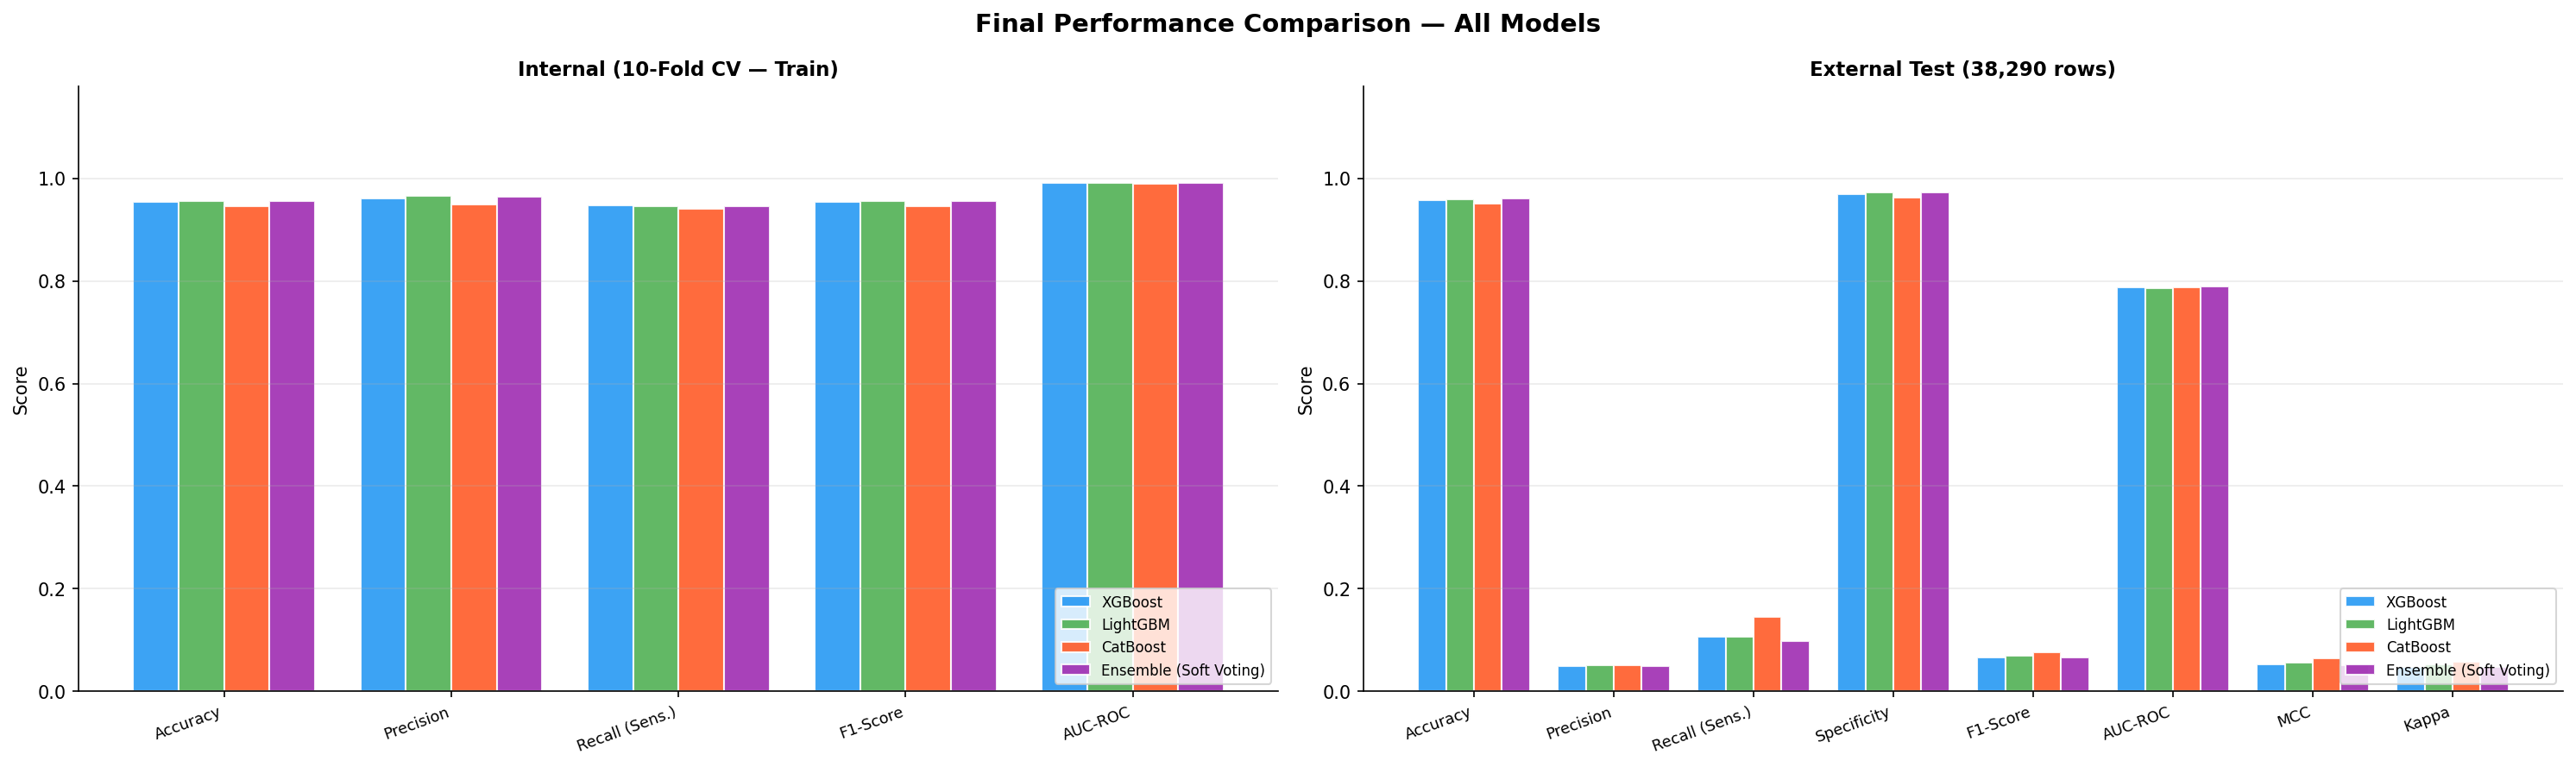

 Saved: 08_final_comparison.png


In [ ]:
metrics_plot = ['Accuracy','Precision','Recall (Sens.)','Specificity',
                'F1-Score','AUC-ROC','MCC','Kappa']

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Final Performance Comparison — All Models',
             fontsize=14, fontweight='bold')

for ax, (data, ds_name) in zip(axes, [
        (pd.DataFrame(res_cv).T.rename(columns={'Recall':'Recall (Sens.)'}),
         'Internal (10-Fold CV — Train)'),
        (df_ext, 'External Test (38,290 rows)')]):

    available = [m for m in metrics_plot if m in data.columns]
    x  = np.arange(len(available)); w=0.2
    colors_bar=['#2196F3','#4CAF50','#FF5722','#9C27B0']
    for i,(mname,col) in enumerate(zip(data.index,colors_bar)):
        vals = [float(data.loc[mname,m]) for m in available]
        ax.bar(x+(i-1.5)*w, vals, w, label=mname,
               color=col, edgecolor='white', alpha=0.88)
    ax.set_xticks(x)
    ax.set_xticklabels(available, rotation=20, ha='right', fontsize=8.5)
    ax.set_ylim(0,1.18); ax.set_ylabel('Score',fontsize=10)
    ax.set_title(ds_name, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('08_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 08_final_comparison.png")
